In [7]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
folder_path = './client'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df_client = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)

In [9]:
folder_path = './server'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df_server = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)

In [10]:
df_combined = pd.merge(
    df_client,
    df_server,
    on=["Transport Protocol", "Scenario", "Distance (m)"],
    how="inner"  # Only rows that exist in both will be kept
)

In [11]:
df_combined

,Transport Protocol,Scenario,Distance (m),Average RTT (ms),Jitter (ms),Transfer Speed (Mbps),Package Loss (%),Package Size (Bytes),Number of Packages
0,TCP,Inner City,30,40.581468,9.434658,70.239204,0.000000,4096,1000
1,TCP,Inner City,30,40.581468,9.434658,252.828583,0.000000,9216,10000
2,TCP,Inner City,30,40.581468,9.434658,151.716370,0.000000,4096,1000
3,TCP,Inner City,30,40.581468,9.434658,4.081970,0.000000,128,100
4,TCP,Inner City,30,40.581468,9.434658,13.119952,0.000000,128,1000
...,...,...,...,...,...,...,...,...,...
733,UDP,Inner City,30,50.511229,8.277380,6.342946,0.000000,128,100
734,UDP,Inner City,30,50.511229,8.277380,248.826736,0.000000,4096,1000
735,UDP,Inner City,30,50.511229,8.277380,33.901630,13.090004,128,10000
736,UDP,Inner City,30,50.511229,8.277380,152.345169,0.000000,4096,100


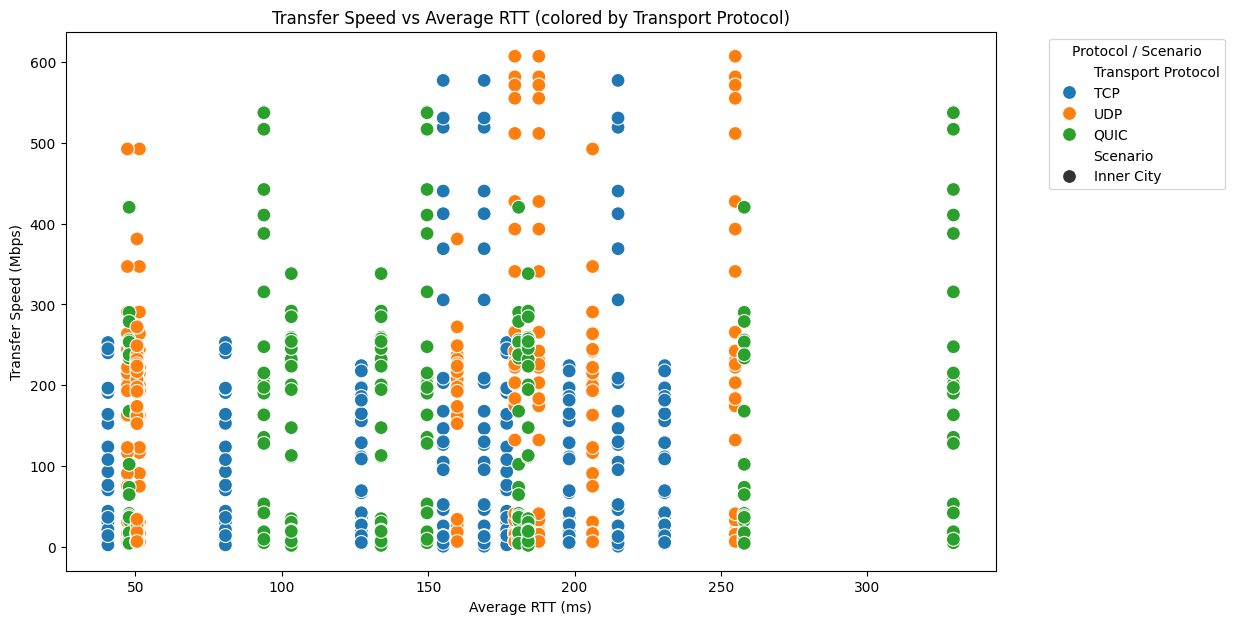

In [12]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Average RTT (ms)', 
    y='Transfer Speed (Mbps)', 
    hue='Transport Protocol', 
    style='Scenario',
    data=df_combined,
    s=100
)
plt.title('Transfer Speed vs Average RTT (colored by Transport Protocol)')
plt.xlabel('Average RTT (ms)')
plt.ylabel('Transfer Speed (Mbps)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

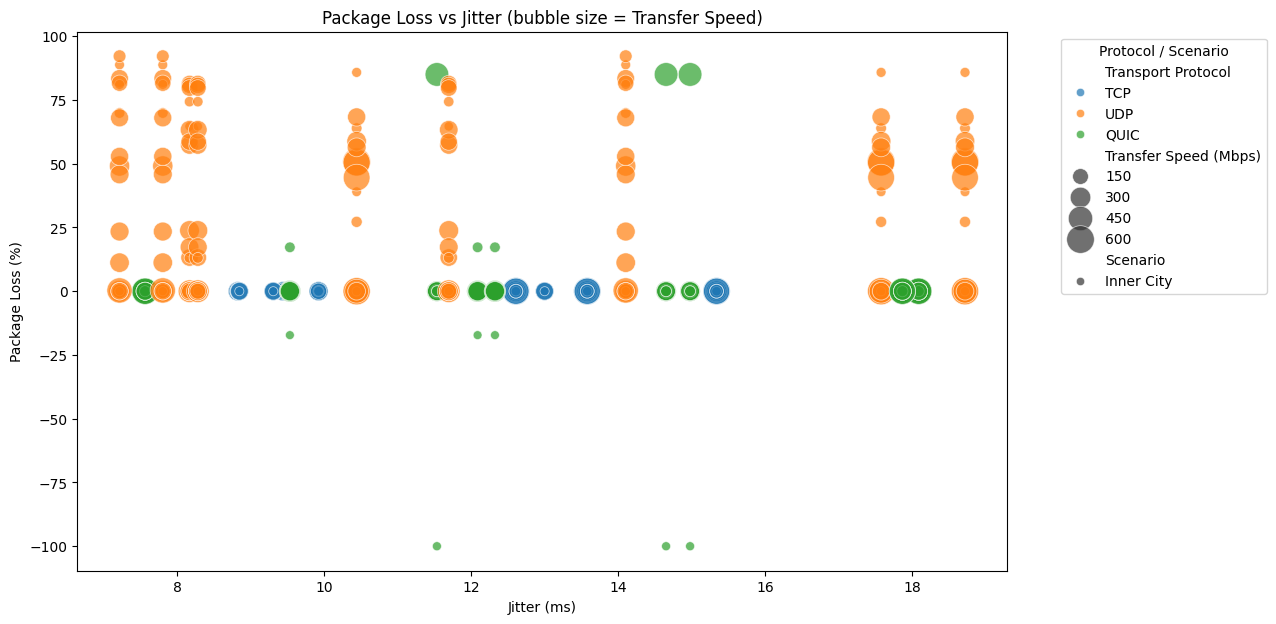

In [13]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Jitter (ms)', 
    y='Package Loss (%)', 
    size='Transfer Speed (Mbps)', 
    hue='Transport Protocol',
    style='Scenario',
    data=df_combined,
    sizes=(40, 400),
    alpha=0.7
)
plt.title('Package Loss vs Jitter (bubble size = Transfer Speed)')
plt.xlabel('Jitter (ms)')
plt.ylabel('Package Loss (%)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

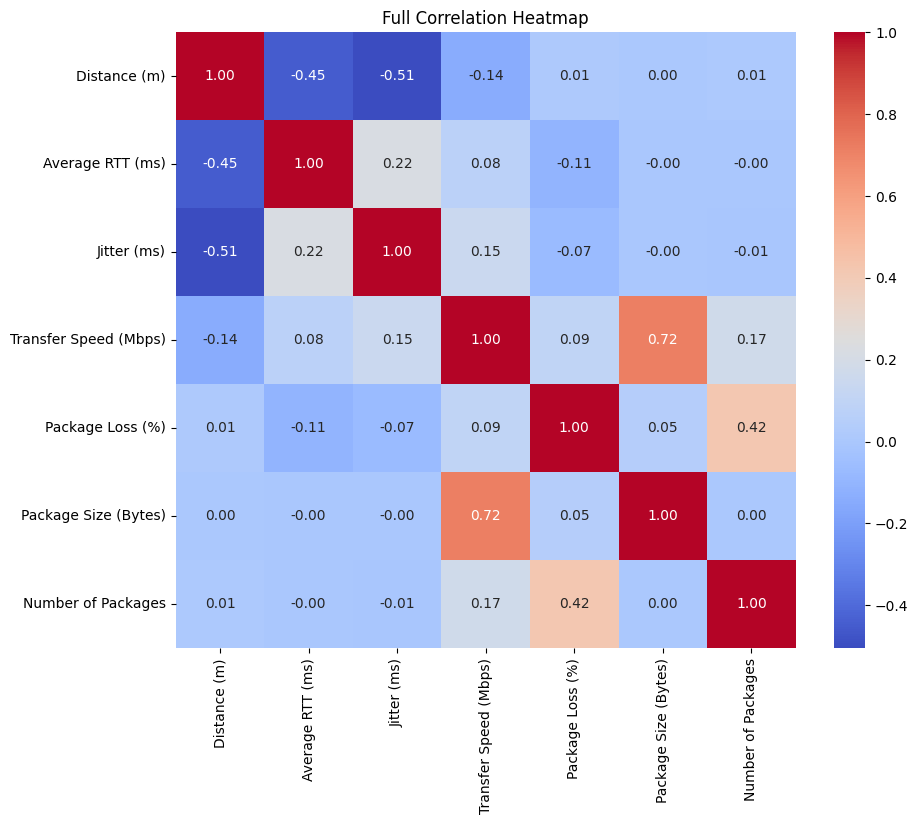

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_combined.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Full Correlation Heatmap')
plt.show()

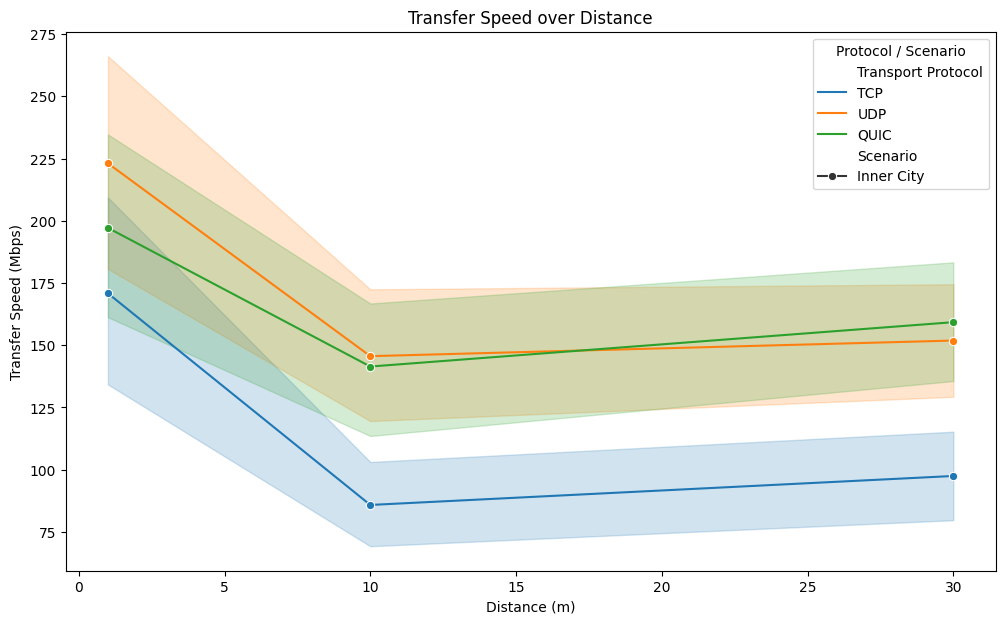

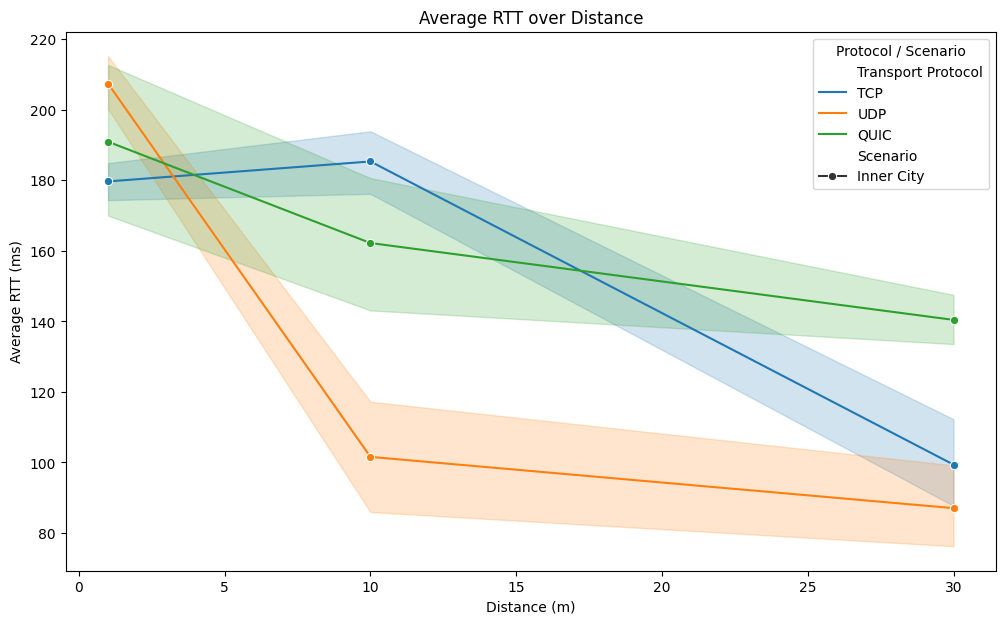

In [15]:
plt.figure(figsize=(12, 7))

# Plot Transfer Speed
sns.lineplot(
    x='Distance (m)', 
    y='Transfer Speed (Mbps)', 
    hue='Transport Protocol', 
    style='Scenario',
    markers=True,
    dashes=False,
    data=df_combined,
    legend='full'
)
plt.title('Transfer Speed over Distance')
plt.xlabel('Distance (m)')
plt.ylabel('Transfer Speed (Mbps)')
plt.legend(title='Protocol / Scenario')
plt.show()

# Plot RTT separately
plt.figure(figsize=(12, 7))
sns.lineplot(
    x='Distance (m)', 
    y='Average RTT (ms)', 
    hue='Transport Protocol', 
    style='Scenario',
    markers=True,
    dashes=False,
    data=df_combined,
    legend='full'
)
plt.title('Average RTT over Distance')
plt.xlabel('Distance (m)')
plt.ylabel('Average RTT (ms)')
plt.legend(title='Protocol / Scenario')
plt.show()